PROBLEM 2 - "Which student profiles are at highest risk of burnout, and can we predict it early?"



STEP 1 CLEAN DATA

In [ ]:
import pandas as pd
df = pd.read_csv("ai_student_impact_dataset.csv")
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [2]:
cols_to_check = ['Weekly_GenAI_Hours', 'Major_Category', 'Year_of_Study', 
                 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 
                 'Anxiety_Level_During_Exams', 'Burnout_Risk_Level' ]

df[cols_to_check].isnull().sum()

Weekly_GenAI_Hours            0
Major_Category                0
Year_of_Study                 0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Anxiety_Level_During_Exams    0
Burnout_Risk_Level            0
dtype: int64

Step 2 — Check Burnout Distribution (Class Balance)

Before building any prediction model, we need to see how many students fall into each burnout category. 

If the groups are heavily unequal, the model will be biased toward the majority group.

In [3]:
df['Burnout_Risk_Level'].value_counts()
()
df['Burnout_Risk_Level'].value_counts(normalize=True).round(3)*100

Burnout_Risk_Level
Medium    42.3
Low       32.7
High      25.0
Name: proportion, dtype: float64

Step 3 — Encode Burnout_Risk_Level to Numbers

Here's the problem: logistic regression is math-based. 

It can't work with text like "Low", "Medium", "High". We need to convert them to numbers.

But the order matters here — Low < Medium < High is a natural ranking. 

So we use ordinal encoding (preserving order), not random numbers.

In [4]:
burnout_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Burnout_Encoded'] = df['Burnout_Risk_Level'].map(burnout_map)

df[['Burnout_Risk_Level', 'Burnout_Encoded']].head(10)

,Burnout_Risk_Level,Burnout_Encoded
0,High,2
1,Low,0
2,Medium,1
3,Medium,1
4,Medium,1
5,High,2
6,Medium,1
7,Medium,1
8,Medium,1
9,High,2


Step 4 — Encode Major_Category and Year_of_Study

In [5]:
df_encoded = pd.get_dummies(df, columns=['Major_Category', 'Year_of_Study'],  drop_first=True)

df_encoded.shape
df_encoded.columns.tolist()

['Student_ID',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level',
 'Burnout_Encoded',
 'Major_Category_Business',
 'Major_Category_Humanities',
 'Major_Category_Medical',
 'Major_Category_STEM',
 'Year_of_Study_Graduate',
 'Year_of_Study_Junior',
 'Year_of_Study_Senior',
 'Year_of_Study_Sophomore']

In [6]:
df_encoded.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,...,Burnout_Risk_Level,Burnout_Encoded,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore
0,100001,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,...,High,2,False,True,False,False,False,False,True,False
1,100002,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,...,Low,0,False,False,True,False,False,True,False,False
2,100003,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,...,Medium,1,True,False,False,False,False,False,False,False
3,100004,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,...,Medium,1,True,False,False,False,False,False,True,False
4,100005,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,...,Medium,1,False,False,False,True,False,False,False,True


Step 5 — Select Features and Define X and Y

Now we tell the model exactly which columns are the inputs (X) and which is the output (Y).

In [7]:
feature_cols = ['Weekly_GenAI_Hours',
                'Traditional_Study_Hours',
                'Perceived_AI_Dependency',
                'Anxiety_Level_During_Exams',
                'Major_Category_Business',
                'Major_Category_Humanities',
                'Major_Category_Medical',
                'Major_Category_STEM',
                'Year_of_Study_Graduate',
                'Year_of_Study_Junior',
                'Year_of_Study_Senior',
                'Year_of_Study_Sophomore']
X = df_encoded[feature_cols]
y = df_encoded['Burnout_Encoded']

print(X.shape)
print(y.shape)

(50000, 12)
(50000,)


Step 6 — Train/Test Split


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Training size: (40000, 12)
Test size: (10000, 12)


Step 7 — Build the Logistic Regression Model

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


Step 8 — Evaluate the Model

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.52      0.49      0.50      3269
      Medium       0.48      0.60      0.53      4195
        High       0.69      0.45      0.54      2536

    accuracy                           0.53     10000
   macro avg       0.56      0.51      0.53     10000
weighted avg       0.54      0.53      0.53     10000



Step 9 — Confusion Matrix

Now let's visualize exactly where the model is getting confused. 

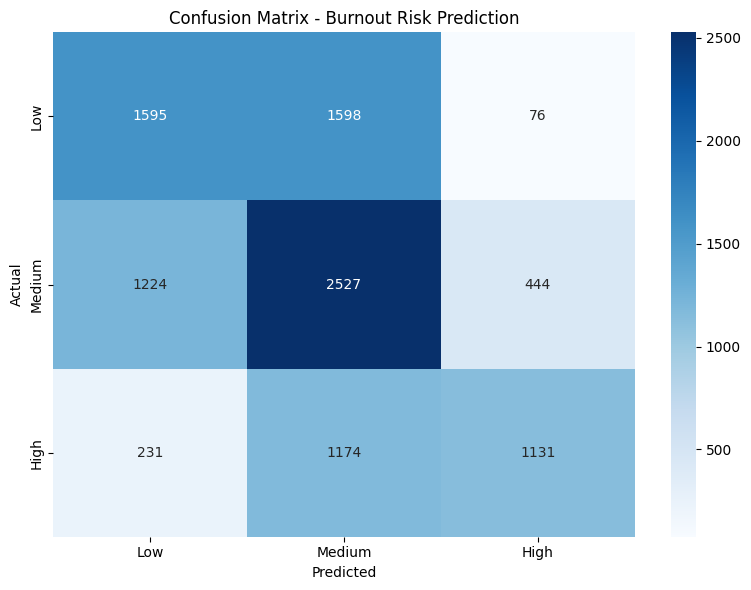

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.title('Confusion Matrix - Burnout Risk Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Step 9 - 

visualize which features actually drove the predictions the most. 

That directly answers the original question: "which student profiles are at highest risk?"

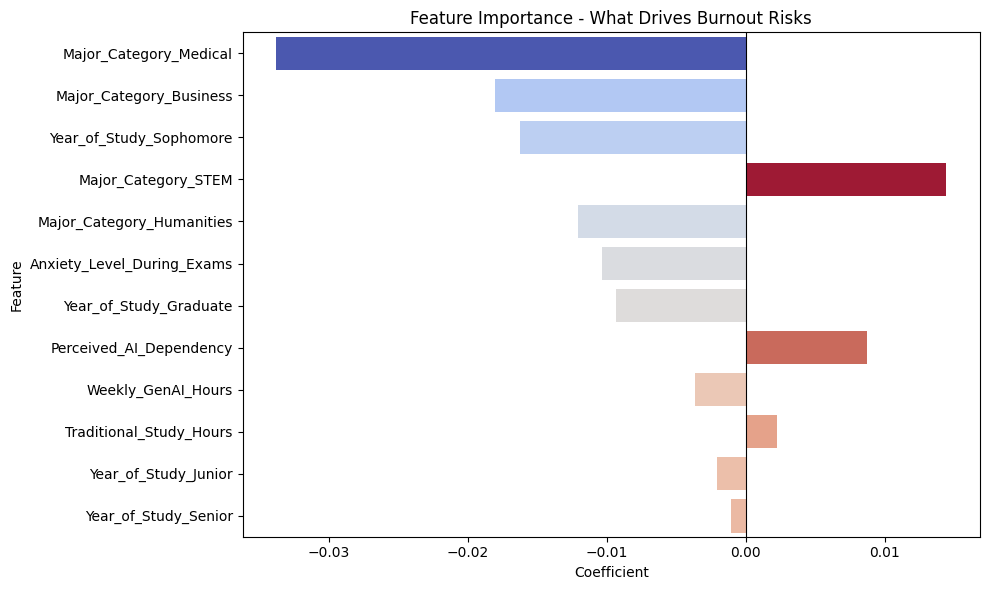

In [15]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[1]
})
coefficients = coefficients.reindex(
    coefficients['Coefficient'].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(10,6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', hue='Coefficient', palette='coolwarm', legend=False)
plt.title('Feature Importance - What Drives Burnout Risks')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Based on the analysis of 50,000 students, the logistic regression model reveals that STEM students are the highest risk group for burnout, particularly those in their upper years who report high perceived AI dependency and spend more hours on traditional studying. The combination of a demanding major, over-reliance on AI tools, and heavy study loads appears to be the most dangerous profile.
On the other end, Medical and Business students show the lowest burnout risk, along with Sophomore year students who are earlier in their academic journey and likely haven't yet accumulated the pressure that builds in later years.
The model predicted burnout level correctly 53% of the time on unseen students — better than random chance, but not strong enough for real-world intervention decisions on its own. The biggest gap is in identifying High burnout students, where the model missed more than half, mostly misclassifying them as Medium risk. In a real school setting, this matters most — those are the students who need help urgently and are being overlooked.
The core takeaway is that burnout risk is not random. It follows a pattern tied to field of study, year level, and how students are using AI — and that pattern is detectable, even with a simple model.